In [1]:
import pandas as pd
import seaborn as srn
import statistics as sts
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, skewnorm

In [2]:
df = pd.read_csv("StudentsPerformance.csv", sep=',')
display (df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [3]:
df.columns = ['genero','raca/etnia','nivel da educacao familiar','almoco','curso de preparacao','nota em matematica','nota em leitura','nota em escrita']
display(df)

,genero,raca/etnia,nivel da educacao familiar,almoco,curso de preparacao,nota em matematica,nota em leitura,nota em escrita
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
agrupado = df.groupby(df['genero']).size()
agrupado

genero
female    518
male      482
dtype: int64

In [5]:
moda = sts.mode(df['genero'])
moda

'female'

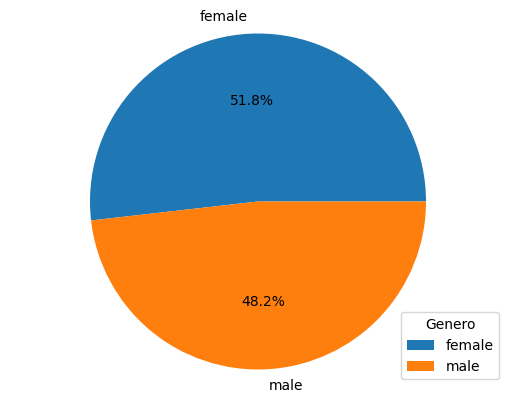

In [6]:
plt.pie(agrupado,labels= ['female','male'],autopct='%1.1f%%')
plt.legend(title='Genero',loc="lower right")
plt.axis('equal')
plt.show()

In [7]:
agrupado = df.groupby(df['raca/etnia']).size()
agrupado

raca/etnia
group A     89
group B    190
group C    319
group D    262
group E    140
dtype: int64

In [8]:
moda = sts.mode(df['raca/etnia'])
moda

'group C'

<Axes: xlabel='raca/etnia'>

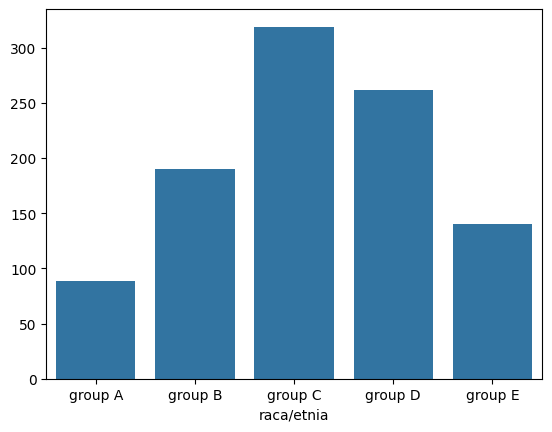

In [9]:
srn.barplot(agrupado)

In [10]:
agrupado = df.groupby(df['nivel da educacao familiar']).size()
agrupado

nivel da educacao familiar
associate's degree    222
bachelor's degree     118
high school           196
master's degree        59
some college          226
some high school      179
dtype: int64

In [11]:
moda = sts.mode(df['nivel da educacao familiar'])
moda

'some college'

Text(0.5, 1.0, 'Nivel da Educação Familiar')

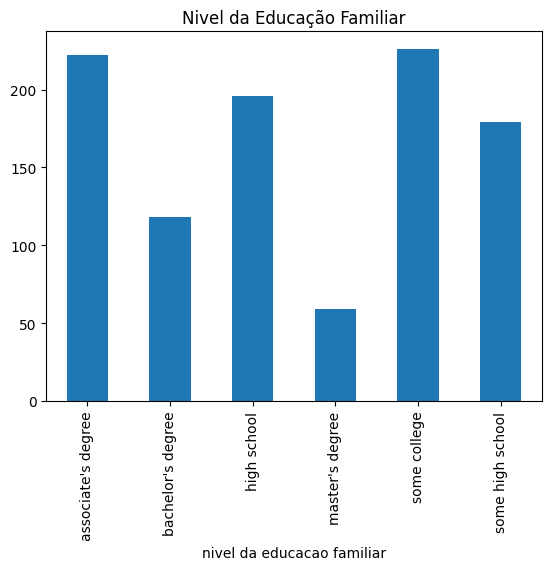

In [12]:
agrupado.plot.bar()
plt.title("Nivel da Educação Familiar")

In [13]:
agrupado = df.groupby(df['almoco']).size()
agrupado

almoco
free/reduced    355
standard        645
dtype: int64

In [14]:
moda = sts.mode(df['almoco'])
moda

'standard'

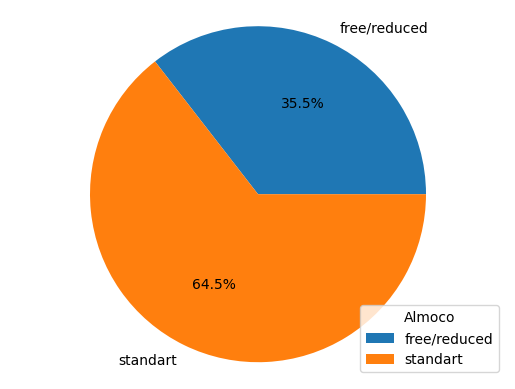

In [15]:
plt.pie(agrupado,labels= ['free/reduced','standart'],autopct='%1.1f%%')
plt.legend(title='Almoco',loc="lower right")
plt.axis('equal')
plt.show()

In [16]:
agrupado = df.groupby(df['curso de preparacao']).size()
agrupado

curso de preparacao
completed    358
none         642
dtype: int64

In [17]:
moda = sts.mode(df['curso de preparacao'])
moda

'none'

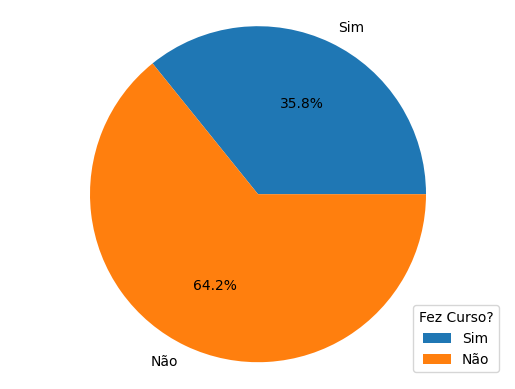

In [18]:
plt.pie(agrupado,labels= ['Sim','Não'],autopct='%1.1f%%')
plt.legend(title='Fez Curso?',loc="lower right")
plt.axis('equal')
plt.show()

In [19]:
agrupado = df.groupby(df['nota em matematica']).size()
agrupado

nota em matematica
0      1
8      1
18     1
19     1
22     1
      ..
96     3
97     6
98     3
99     3
100    7
Length: 81, dtype: int64

<Axes: xlabel='nota em matematica', ylabel='Count'>

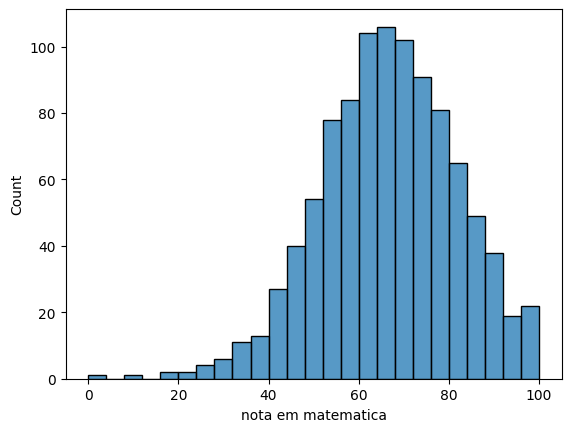

In [20]:
srn.histplot(df['nota em matematica'])

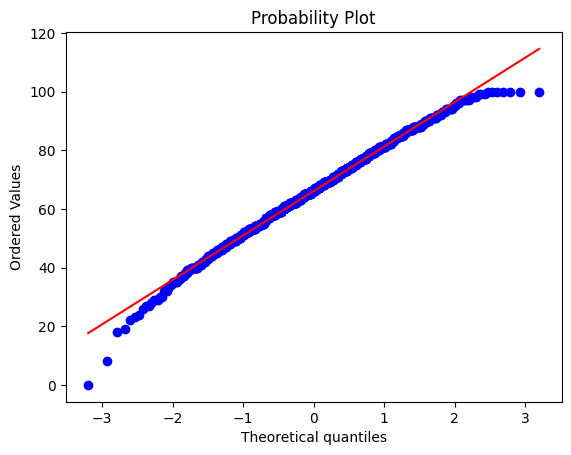

In [21]:
fig, ax = plt.subplots()
stats.probplot(df['nota em matematica'], fit=True, plot=ax)
plt.show()

In [22]:
# Valores de P acima de 0.5 representam dados confiaveis
stats.shapiro(df['nota em matematica'])

ShapiroResult(statistic=np.float64(0.9931513872437832), pvalue=np.float64(0.00014545719606603633))

In [23]:
media = np.mean(df['nota em matematica'])
mediana = np.median(df['nota em matematica'])
moda = sts.mode(df['nota em matematica'])
quartis = np.quantile(df['nota em matematica'], [0 , 0.25 , 0.50 , 0.75 , 1])
dp = np.std(df['nota em matematica'], ddof=1)
display('A media e:', media)
display('A mediana e:', mediana)
display('A moda e:',moda)
display('Os quartis são:', quartis)
display('O desvio padrão e de:',dp)

'A media e:'

np.float64(66.089)

'A mediana e:'

np.float64(66.0)

'A moda e:'

65

'Os quartis são:'

array([  0.,  57.,  66.,  77., 100.])

'O desvio padrão e de:'

np.float64(15.16308009600945)

In [24]:
#calculando probabilidade de cair valores nos primeiros 25%
p25 = norm.cdf(quartis[1],media,dp)
p25 = (p25).round(3)
display("A chance de um valor entre 0% e 25%:",p25)
#calculando probabilidade de cair valores entre 25%-50%
s25 = norm.cdf(quartis[2],media,dp)
s25 =(s25).round(3)
s25= s25 - p25
display("A chance de um valor entre os 25% e 50%:",s25)
#calculando probabilidade de cair valores entre 50%-75%
t25 = norm.cdf(quartis[3],media,dp)
t25 = (t25).round(3)
t25 = t25 - s25 - p25
display("A chance de um valor entre os 50% e 75%:",t25)
#calculando probabilidade de cair valores entre 75%-100%
q25 = norm.cdf(quartis[4],media,dp)
q25 = (q25).round(3)
q25 = q25 - t25 - s25 - p25
display("A chance de um valor entre os 75% e 1oo%:",q25)


'A chance de um valor entre 0% e 25%:'

np.float64(0.274)

'A chance de um valor entre os 25% e 50%:'

np.float64(0.22399999999999998)

'A chance de um valor entre os 50% e 75%:'

np.float64(0.266)

'A chance de um valor entre os 75% e 1oo%:'

np.float64(0.22299999999999998)

In [25]:
agrupado = df.groupby(df['nota em leitura']).size()
agrupado

nota em leitura
17      1
23      1
24      2
26      1
28      1
       ..
95      8
96      4
97      5
99      3
100    17
Length: 72, dtype: int64

<Axes: xlabel='nota em leitura', ylabel='Count'>

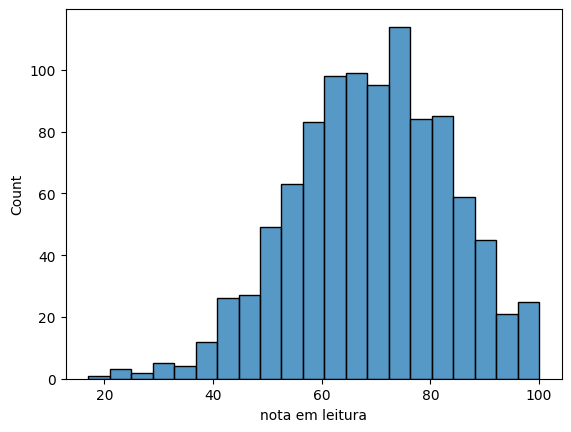

In [26]:
srn.histplot(df['nota em leitura'])

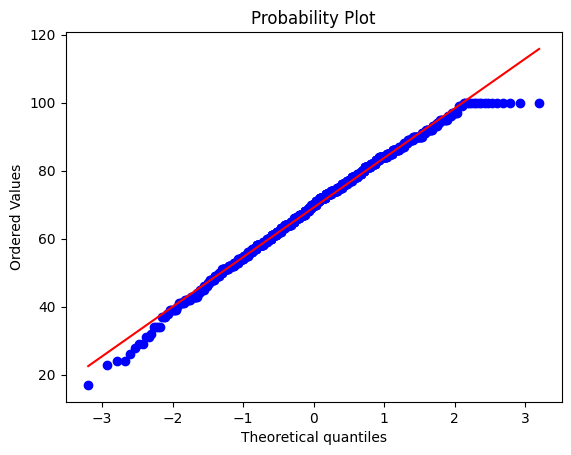

In [27]:
fig, ax = plt.subplots()
stats.probplot(df['nota em leitura'], fit=True, plot=ax)
plt.show()

In [28]:
# Valores de P acima de 0.5 representam dados confiaveis
stats.shapiro(df['nota em leitura'])

ShapiroResult(statistic=np.float64(0.9929205131817913), pvalue=np.float64(0.00010554314738064095))

In [29]:
media = np.mean(df['nota em leitura'])
mediana = np.median(df['nota em leitura'])
moda = sts.mode(df['nota em leitura'])
quartis = np.quantile(df['nota em leitura'], [0 ,0.25 , 0.50 , 0.75 , 1])
dp = np.std(df['nota em leitura'], ddof=1)
display('A media e:', media)
display('A mediana e:', mediana)
display('A moda e:',moda)
display('Os quartis são:', quartis)
display('O desvio padrão e de:',dp)

'A media e:'

np.float64(69.169)

'A mediana e:'

np.float64(70.0)

'A moda e:'

72

'Os quartis são:'

array([ 17.,  59.,  70.,  79., 100.])

'O desvio padrão e de:'

np.float64(14.600191937252216)

In [30]:
#calculando probabilidade de cair valores nos primeiros 25%
p25 = norm.cdf(quartis[1],media,dp)
p25 = (p25).round(3)
display("A chance de um valor entre 0% e 25%:",p25)
#calculando probabilidade de cair valores entre 25%-50%
s25 = norm.cdf(quartis[2],media,dp)
s25 =(s25).round(3)
s25= s25 - p25
display("A chance de um valor entre os 25% e 50%:",s25)
#calculando probabilidade de cair valores entre 50%-75%
t25 = norm.cdf(quartis[3],media,dp)
t25 = (t25).round(3)
t25 = t25 - s25 - p25
display("A chance de um valor entre os 50% e 75%:",t25)
#calculando probabilidade de cair valores entre 75%-100%
q25 = norm.cdf(quartis[4],media,dp)
q25 = (q25).round(3)
q25 = q25 - t25 - s25 - p25
display("A chance de um valor entre os 75% e 1oo%:",q25)

'A chance de um valor entre 0% e 25%:'

np.float64(0.243)

'A chance de um valor entre os 25% e 50%:'

np.float64(0.28)

'A chance de um valor entre os 50% e 75%:'

np.float64(0.22699999999999998)

'A chance de um valor entre os 75% e 1oo%:'

np.float64(0.23299999999999998)

In [31]:
agrupado = df.groupby(df['nota em escrita']).size()
agrupado

nota em escrita
10      1
15      1
19      1
22      1
23      1
       ..
96      4
97      2
98      2
99      4
100    14
Length: 77, dtype: int64

<Axes: xlabel='nota em escrita', ylabel='Count'>

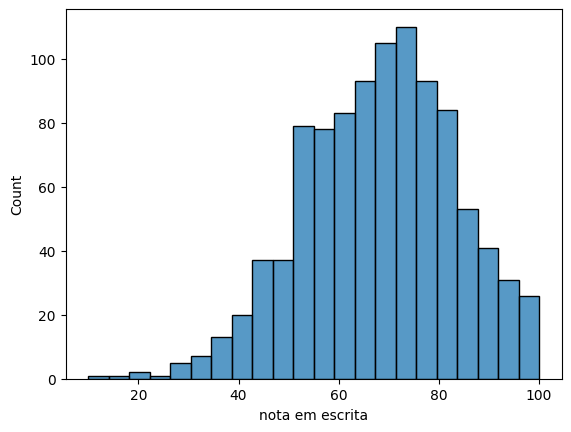

In [32]:
srn.histplot(df['nota em escrita'])

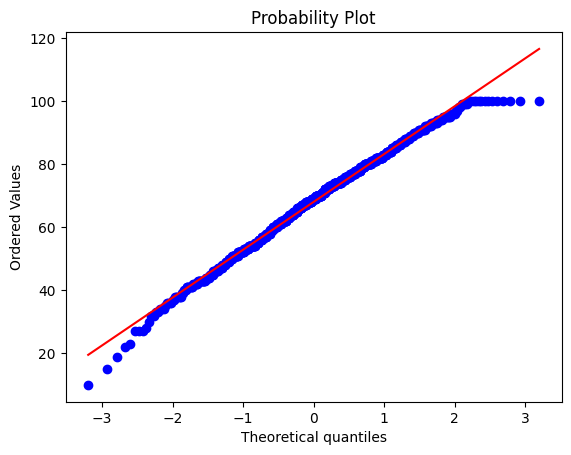

In [33]:
fig, ax = plt.subplots()
stats.probplot(df['nota em escrita'], fit=True, plot=ax)
plt.show()

In [34]:
# Valores de P acima de 0.5 representam dados confiaveis
stats.shapiro(df['nota em escrita'])

ShapiroResult(statistic=np.float64(0.991964462962203), pvalue=np.float64(2.9215498810124692e-05))

In [35]:
media = np.mean(df['nota em escrita'])
mediana = np.median(df['nota em escrita'])
moda = sts.mode(df['nota em escrita'])
quartis = np.quantile(df['nota em escrita'], [0 , 0.25 , 0.50 , 0.75 , 1])
dp = np.std(df['nota em escrita'], ddof=1)
display('A media e:', media)
display('A mediana e:', mediana)
display('A moda e:',moda)
display('Os quartis são:', quartis)
display('O desvio padrão e de:',dp)

'A media e:'

np.float64(68.054)

'A mediana e:'

np.float64(69.0)

'A moda e:'

74

'Os quartis são:'

array([ 10.  ,  57.75,  69.  ,  79.  , 100.  ])

'O desvio padrão e de:'

np.float64(15.19565701086965)

In [36]:
#calculando probabilidade de cair valores nos primeiros 25%
p25 = norm.cdf(quartis[1],media,dp)
p25 = (p25).round(3)
display("A chance de um valor entre 0% e 25%:",p25)
#calculando probabilidade de cair valores entre 25%-50%
s25 = norm.cdf(quartis[2],media,dp)
s25 =(s25).round(3)
s25= s25 - p25
display("A chance de um valor entre os 25% e 50%:",s25)
#calculando probabilidade de cair valores entre 50%-75%
t25 = norm.cdf(quartis[3],media,dp)
t25 = (t25).round(3)
t25 = t25 - s25 - p25
display("A chance de um valor entre os 50% e 75%:",t25)
#calculando probabilidade de cair valores entre 75%-100%
q25 = norm.cdf(quartis[4],media,dp)
q25 = (q25).round(3)
q25 = q25 - t25 - s25 - p25
display("A chance de um valor entre os 75% e 1oo%:",q25)

'A chance de um valor entre 0% e 25%:'

np.float64(0.249)

'A chance de um valor entre os 25% e 50%:'

np.float64(0.276)

'A chance de um valor entre os 50% e 75%:'

np.float64(0.239)

'A chance de um valor entre os 75% e 1oo%:'

np.float64(0.21799999999999997)